# 13. 全攻击类型评测

本notebook测试11.ipynb和12.ipynb中所有模型对所有攻击类型的鲁棒性。

## 攻击类型
- **L∞攻击**: FGSM, PGD(L∞), CW(L∞)
- **L2攻击**: PGD(L2)
- **混合攻击**: MSD(L2+L∞)
- **遮蔽攻击**: 固定遮蔽, 自适应遮蔽

## 测试模型
- Standard: 标准训练模型
- PGD-AT: PGD对抗性训练
- FGSM-AT: FGSM对抗性训练
- Occlusion-AT(Fixed): 固定遮蔽攻击对抗性训练
- Mix-AT(Fixed,10ep): 固定遮蔽+PGD混合训练(10轮)
- Occlusion-AT(Adaptive): 自适应遮蔽攻击对抗性训练
- Mix-AT(Adaptive,50ep): 自适应遮蔽+PGD混合训练(50轮)

## 13.1 导入模块

In [11]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')

import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 强制重新加载模块（避免缓存问题）
import importlib
import pgd
import occlusion_attack
importlib.reload(pgd)
importlib.reload(occlusion_attack)

# 导入攻击类
from pgd import LinfPGD, L2PGD, FGSM, CWAttack, MSDAttack
from occlusion_attack import OcclusionAttack, AdaptiveOcclusionAttack

# 导入其他模块
from models import LeNet5
from utils import load_mnist_test
import test; test_fn = test.test

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print('模块导入完成')

Device: cuda
模块导入完成


## 13.2 加载模型

In [12]:
# 所有模型配置（来自11.ipynb和12.ipynb）
model_ckpts = {
    # 11.ipynb 模型
    'Standard': './save_model/50epoch/mnist_lenet5.pth',
    'PGD-AT': './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth',
    'FGSM-AT': './save_model/50epoch/mnist_lenet5_FGSM_AT.pth',
    'Occlusion-AT(Fixed)': './save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth',
    'Mix-AT(Fixed,10ep)': './save_model/10epoch/mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth',
    # 12.ipynb 模型
    'Occlusion-AT(Adaptive)': './save_model/50epoch/mnist_lenet5_AdaptiveOcclusionAT_5_3.pth',
    'Mix-AT(Adaptive,50ep)': './save_model/50epoch/mnist_lenet5_AdaptiveMixedAT_0.5_5_3.pth',
}

# 加载模型
models = {}
for name, path in model_ckpts.items():
    if os.path.exists(path):
        net = LeNet5().to(device)
        state = torch.load(path, map_location=device, weights_only=False)
        net.load_state_dict(state['net'])
        net.eval()
        models[name] = net
        print(f'Loaded: {name}')
    else:
        print(f'Missing: {name} -> {path}')

print(f'\n共加载 {len(models)} 个模型')

Loaded: Standard
Loaded: PGD-AT
Loaded: FGSM-AT
Loaded: Occlusion-AT(Fixed)
Loaded: Mix-AT(Fixed,10ep)
Loaded: Occlusion-AT(Adaptive)
Loaded: Mix-AT(Adaptive,50ep)

共加载 7 个模型


## 13.3 定义攻击

In [13]:
# 攻击参数
EPS_LINF = 0.1
EPS_L2 = 1.0
NUM_STEPS = 20
STEP_SIZE_LINF = 0.025
STEP_SIZE_L2 = 0.1

# 遮蔽参数
N_OCCLU = 5
R_OCCLU = 3
C_COLOR = 0.0

def create_attacks(model):
    """创建所有攻击实例"""
    attacks = {}
    
    # L∞攻击
    attacks['FGSM'] = FGSM(model, eps=EPS_LINF)
    attacks['PGD(Linf)'] = LinfPGD(model, eps=EPS_LINF, step=NUM_STEPS, 
                                   step_size=STEP_SIZE_LINF, random_start=True)
    attacks['CW(Linf)'] = CWAttack(model, eps=EPS_LINF, step=NUM_STEPS,
                                   step_size=STEP_SIZE_LINF, num_classes=10)
    
    # L2攻击
    attacks['PGD(L2)'] = L2PGD(model, eps=EPS_L2, step=NUM_STEPS,
                               step_size=STEP_SIZE_L2, random_start=True)
    
    # 混合攻击
    attacks['MSD'] = MSDAttack(model, epsilon_l_inf=EPS_LINF, epsilon_l_2=EPS_L2,
                               alpha_l_inf=STEP_SIZE_LINF, alpha_l_2=STEP_SIZE_L2,
                               num_iter=NUM_STEPS)
    
    # 遮蔽攻击
    attacks['Occl(Fixed)'] = OcclusionAttack(model, top_k=9, occlu_color=C_COLOR, kernel_size=3)
    attacks['Occl(Adaptive)'] = AdaptiveOcclusionAttack(model, N=N_OCCLU, R=R_OCCLU, c=C_COLOR)
    
    return attacks

print('攻击定义完成')

攻击定义完成


## 13.4 执行评测

In [14]:
# 加载测试集
imgs, lbls = load_mnist_test()
print(f'测试集大小: {imgs.shape[0]}')

测试集大小: 10000


In [15]:
# 评测函数
def evaluate_all_models(models, imgs, lbls):
    """评测所有模型对所有攻击的鲁棒性"""
    results = []
    
    for model_name, model in models.items():
        print(f'\n评测: {model_name}')
        result = {'Model': model_name}
        
        # 干净样本
        clean_acc, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')
        result['Clean'] = round(clean_acc, 2)
        print(f'  Clean: {clean_acc:.2f}%')
        
        # 各类攻击
        attacks = create_attacks(model)
        for attack_name, attack in attacks.items():
            acc, _ = test_fn(nn.Sequential(attack, model), imgs, lbls, bs=250, mode='attack')
            result[attack_name] = round(acc, 2)
            print(f'  {attack_name}: {acc:.2f}%')
        
        results.append(result)
    
    return pd.DataFrame(results)

# 执行评测
print('=' * 60)
print('全攻击类型统一评测')
print('=' * 60)

df = evaluate_all_models(models, imgs, lbls)

全攻击类型统一评测

评测: Standard
  Clean: 99.00%
  FGSM: 79.46%
  PGD(Linf): 33.72%
  CW(Linf): 33.99%
  PGD(L2): 67.84%
  MSD: 35.63%
  Occl(Fixed): 28.64%
  Occl(Adaptive): 16.66%

评测: PGD-AT
  Clean: 99.30%
  FGSM: 96.10%
  PGD(Linf): 95.02%
  CW(Linf): 95.04%
  PGD(L2): 92.77%
  MSD: 95.03%
  Occl(Fixed): 49.17%
  Occl(Adaptive): 25.42%

评测: FGSM-AT
  Clean: 99.20%
  FGSM: 95.68%
  PGD(Linf): 90.66%
  CW(Linf): 90.94%
  PGD(L2): 91.55%
  MSD: 91.05%
  Occl(Fixed): 54.14%
  Occl(Adaptive): 25.55%

评测: Occlusion-AT(Fixed)
  Clean: 95.75%
  FGSM: 3.24%
  PGD(Linf): 0.00%
  CW(Linf): 0.00%
  PGD(L2): 0.33%
  MSD: 0.00%
  Occl(Fixed): 97.34%
  Occl(Adaptive): 64.23%

评测: Mix-AT(Fixed,10ep)
  Clean: 98.53%
  FGSM: 93.50%
  PGD(Linf): 91.75%
  CW(Linf): 91.65%
  PGD(L2): 89.96%
  MSD: 91.79%
  Occl(Fixed): 84.43%
  Occl(Adaptive): 59.23%

评测: Occlusion-AT(Adaptive)
  Clean: 98.48%
  FGSM: 39.01%
  PGD(Linf): 0.19%
  CW(Linf): 0.31%
  PGD(L2): 3.55%
  MSD: 0.86%
  Occl(Fixed): 90.42%
  Occl(Adaptiv

## 13.5 结果展示

In [16]:
# 显示结果表格
print('\n' + '=' * 60)
print('评测结果汇总')
print('=' * 60)
print(df.to_string(index=False))


评测结果汇总
                 Model  Clean  FGSM  PGD(Linf)  CW(Linf)  PGD(L2)   MSD  Occl(Fixed)  Occl(Adaptive)
              Standard  99.00 79.46      33.72     33.99    67.84 35.63        28.64           16.66
                PGD-AT  99.30 96.10      95.02     95.04    92.77 95.03        49.17           25.42
               FGSM-AT  99.20 95.68      90.66     90.94    91.55 91.05        54.14           25.55
   Occlusion-AT(Fixed)  95.75  3.24       0.00      0.00     0.33  0.00        97.34           64.23
    Mix-AT(Fixed,10ep)  98.53 93.50      91.75     91.65    89.96 91.79        84.43           59.23
Occlusion-AT(Adaptive)  98.48 39.01       0.19      0.31     3.55  0.86        90.42           87.03
 Mix-AT(Adaptive,50ep)  98.90 94.01      91.41     91.49    88.75 91.46        87.69           77.50


In [17]:
# 保存结果
os.makedirs('./results_figures', exist_ok=True)
df.to_csv('./results_figures/all_models_all_attacks_evaluation.csv', index=False)
print('结果已保存至: ./results_figures/all_models_all_attacks_evaluation.csv')

结果已保存至: ./results_figures/all_models_all_attacks_evaluation.csv


## 13.6 结果可视化

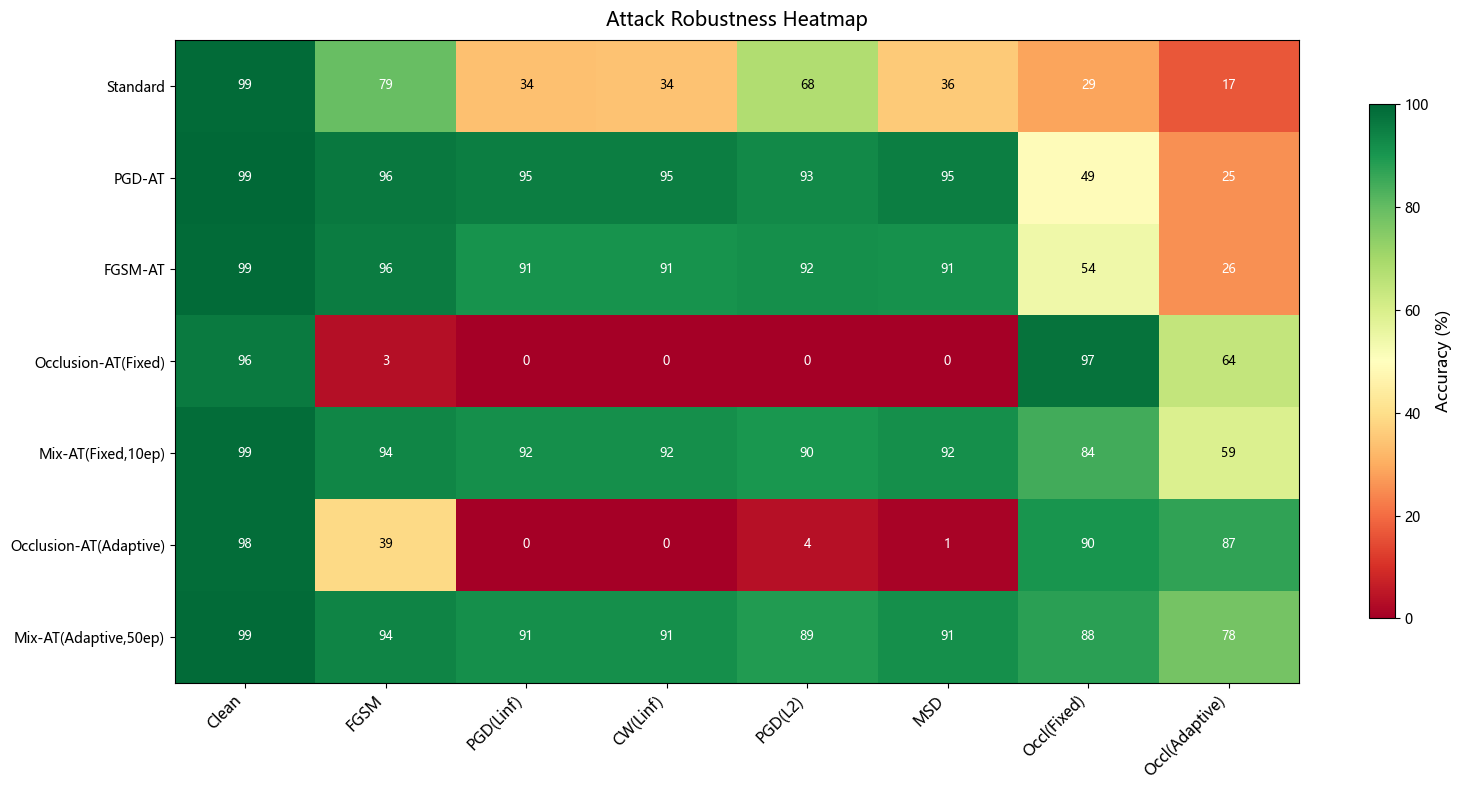

In [18]:
# 绘制热力图
def plot_heatmap(df, title='Attack Robustness Heatmap'):
    """绘制攻击鲁棒性热力图"""
    attack_cols = [c for c in df.columns if c != 'Model']
    data = df[attack_cols].values.astype(float)
    models_list = df['Model'].values
    
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    
    ax.set_xticks(range(len(attack_cols)))
    ax.set_xticklabels(attack_cols, rotation=45, ha='right', fontsize=11)
    ax.set_yticks(range(len(models_list)))
    ax.set_yticklabels(models_list, fontsize=10)
    
    # 添加数值标注
    for i in range(len(models_list)):
        for j in range(len(attack_cols)):
            val = data[i, j]
            color = 'white' if val < 30 or val > 70 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', color=color, fontsize=9)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Accuracy (%)', fontsize=12)
    
    ax.set_title(title, fontsize=14, pad=10)
    plt.tight_layout()
    plt.savefig('./results_figures/all_models_all_attacks_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_heatmap(df)

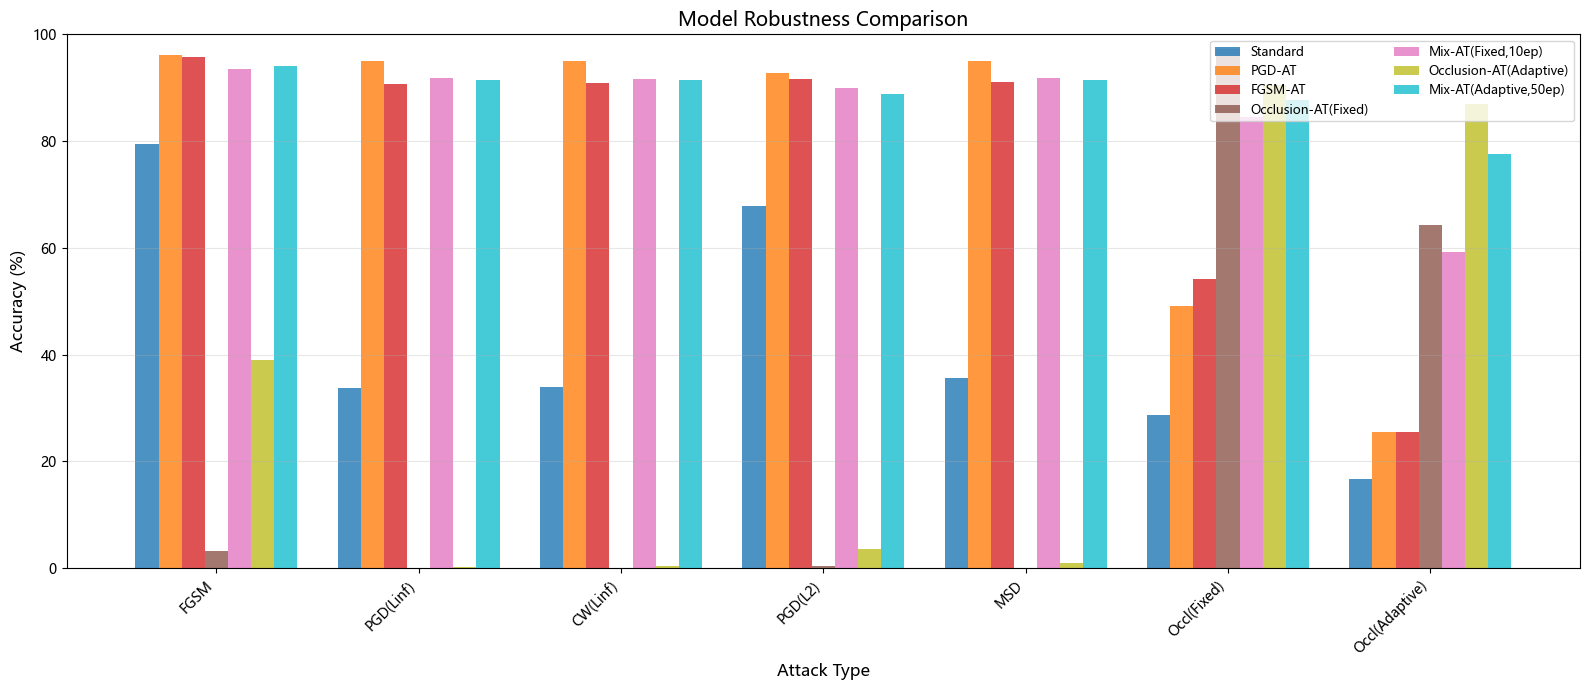

In [19]:
# 绘制分组柱状图
def plot_grouped_bar(df):
    """绘制分组柱状图比较各模型的鲁棒性"""
    attack_cols = [c for c in df.columns if c not in ['Model', 'Clean']]
    
    x = np.arange(len(attack_cols))
    width = 0.8 / len(df)
    
    fig, ax = plt.subplots(figsize=(16, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, len(df)))
    
    for i, (_, row) in enumerate(df.iterrows()):
        values = [row[c] for c in attack_cols]
        ax.bar(x + i * width, values, width, label=row['Model'], color=colors[i], alpha=0.8)
    
    ax.set_xlabel('Attack Type', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Model Robustness Comparison', fontsize=14)
    ax.set_xticks(x + width * (len(df) - 1) / 2)
    ax.set_xticklabels(attack_cols, rotation=45, ha='right', fontsize=10)
    ax.legend(loc='upper right', fontsize=9, ncol=2)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./results_figures/all_models_all_attacks_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_grouped_bar(df)

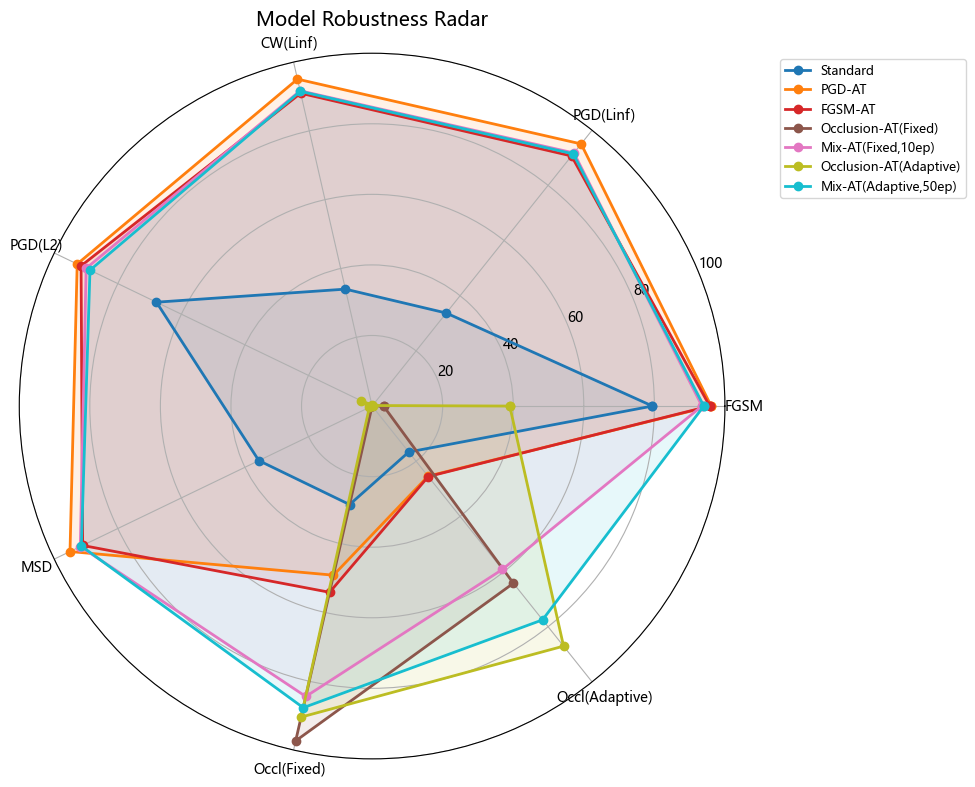

In [20]:
# 绘制雷达图
def plot_radar(df):
    """绘制雷达图比较各模型鲁棒性"""
    attack_cols = [c for c in df.columns if c not in ['Model', 'Clean']]
    N = len(attack_cols)
    
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    colors = plt.cm.tab10(np.linspace(0, 1, len(df)))
    
    for i, (_, row) in enumerate(df.iterrows()):
        values = [row[c] for c in attack_cols]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(attack_cols, fontsize=10)
    ax.set_ylim(0, 100)
    ax.set_title('Model Robustness Radar', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0), fontsize=9)
    
    plt.tight_layout()
    plt.savefig('./results_figures/all_models_all_attacks_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_radar(df)

## 13.7 关键发现

### 攻击鲁棒性发现

1. **PGD-AT** 对 L∞ 攻击（FGSM, PGD, CW, MSD）防御效果最好
2. **Occlusion-AT(Fixed)** 对固定遮蔽攻击防御最好（97.34%），但对其他攻击极其脆弱
3. **Occlusion-AT(Adaptive)** 对自适应遮蔽攻击防御最好（87.03%）
4. **Mix-AT(Adaptive,50ep)** 实现了最佳平衡：同时对 L∞ 攻击和遮蔽攻击都有良好防御

## 13.8 Gini系数分析

Gini系数衡量归因图（attribution map）的不平等程度：
- **低Gini系数**：归因均匀分布在所有像素上 → 模型决策更加分散
- **高Gini系数**：归因集中在少数像素上 → 模型决策集中在关键区域

本节计算所有模型的Gini系数，分析模型决策特征与鲁棒性的关系。

In [ ]:
def compute_saliency_map(model, x, y):
    """计算模型的saliency map（归因图）
    
    参数:
        model: 神经网络模型
        x: 输入图像 [B, C, H, W]
        y: 标签 [B,]
    
    返回:
        saliency_map: 梯度归因图 [B, C, H, W]
    """
    model.eval()
    x = x.clone().requires_grad_(True)
    output = model(x)
    scores = output.gather(1, y.view(-1, 1))
    saliency_map = torch.autograd.grad(scores, x, torch.ones_like(scores))[0]
    return saliency_map.abs()

def gini_coefficient(arr):
    """计算单个向量的Gini系数
    
    Gini = (n+1 - 2*Σ(i*sorted[i])/Σ(sorted[i])) / n
    """
    arr = arr.flatten()
    n = len(arr)
    sorted_arr = torch.sort(torch.abs(arr))[0]
    coeff = torch.flip(torch.arange(1, n + 1, device=arr.device, dtype=arr.dtype), [0])
    sum_of_arr = torch.sum(sorted_arr)
    sum_of_mult = torch.sum(coeff * sorted_arr)
    if sum_of_arr == 0:
        return 0.0
    return ((n + 1 - 2 * sum_of_mult / sum_of_arr) / n).item()

def compute_gini_for_model(model, imgs, lbls, batch_size=500):
    """计算模型在数据集上的平均Gini系数"""
    gini_values = []
    
    for i in range(0, len(imgs), batch_size):
        batch_x = imgs[i:i+batch_size].to(device)
        batch_y = lbls[i:i+batch_size].to(device)
        
        with torch.enable_grad():
            saliency = compute_saliency_map(model, batch_x, batch_y)
        
        for j in range(saliency.shape[0]):
            g = gini_coefficient(saliency[j].detach().cpu())
            gini_values.append(g)
    
    return np.mean(gini_values), np.std(gini_values)

print('Gini系数计算函数定义完成')

In [ ]:
# 计算所有模型的Gini系数
print('=' * 60)
print('计算各模型的Gini系数')
print('=' * 60)

gini_results = []
for model_name, model in models.items():
    print(f'计算: {model_name}...', end=' ')
    mean_gini, std_gini = compute_gini_for_model(model, imgs, lbls, batch_size=500)
    gini_results.append({
        'Model': model_name,
        'Gini_Mean': round(mean_gini, 4),
        'Gini_Std': round(std_gini, 4)
    })
    print(f'Gini = {mean_gini:.4f} ± {std_gini:.4f}')

gini_df = pd.DataFrame(gini_results)
print('\n' + '=' * 60)
print('Gini系数汇总')
print('=' * 60)
print(gini_df.to_string(index=False))

In [ ]:
# Gini系数可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 柱状图
ax1 = axes[0]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(gini_df)))
bars = ax1.bar(range(len(gini_df)), gini_df['Gini_Mean'].values, 
               yerr=gini_df['Gini_Std'].values, capsize=3, color=colors, alpha=0.8)
ax1.set_xticks(range(len(gini_df)))
ax1.set_xticklabels(gini_df['Model'].values, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Gini Coefficient', fontsize=12)
ax1.set_title('Gini Coefficient Comparison', fontsize=13)
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# 添加数值标注
for i, (bar, val) in enumerate(zip(bars, gini_df['Gini_Mean'].values)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# 与干净样本准确率的关系
ax2 = axes[1]
clean_accs = [df[df['Model']==m]['Clean'].values[0] for m in gini_df['Model']]
ax2.scatter(gini_df['Gini_Mean'], clean_accs, s=100, c=colors, alpha=0.8, edgecolors='black')
for i, model in enumerate(gini_df['Model']):
    ax2.annotate(model, (gini_df['Gini_Mean'].iloc[i], clean_accs[i]), 
                 fontsize=8, ha='center', va='bottom')
ax2.set_xlabel('Gini Coefficient', fontsize=12)
ax2.set_ylabel('Clean Accuracy (%)', fontsize=12)
ax2.set_title('Gini vs Clean Accuracy', fontsize=13)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./results_figures/gini_coefficient_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 合并Gini系数与攻击鲁棒性结果
merged_df = df.merge(gini_df, on='Model')

# 计算平均攻击鲁棒性（不含Clean）
attack_cols = [c for c in df.columns if c not in ['Model', 'Clean']]
merged_df['Avg_Robustness'] = merged_df[attack_cols].mean(axis=1).round(2)

print('=' * 60)
print('完整结果汇总（含Gini系数）')
print('=' * 60)
print(merged_df.to_string(index=False))

# 保存完整结果
merged_df.to_csv('./results_figures/complete_evaluation_with_gini.csv', index=False)
print('\n结果已保存至: ./results_figures/complete_evaluation_with_gini.csv')

In [ ]:
# Gini系数 vs 平均鲁棒性 散点图
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(merged_df)))
scatter = ax.scatter(merged_df['Gini_Mean'], merged_df['Avg_Robustness'], 
                     s=150, c=colors, alpha=0.8, edgecolors='black', linewidth=1.5)

for i, row in merged_df.iterrows():
    ax.annotate(row['Model'], (row['Gini_Mean'], row['Avg_Robustness']), 
                fontsize=9, ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points')

ax.set_xlabel('Gini Coefficient (lower = more uniform attribution)', fontsize=12)
ax.set_ylabel('Average Attack Robustness (%)', fontsize=12)
ax.set_title('Gini Coefficient vs Average Robustness', fontsize=14)
ax.grid(alpha=0.3)

# 添加趋势线
z = np.polyfit(merged_df['Gini_Mean'], merged_df['Avg_Robustness'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged_df['Gini_Mean'].min(), merged_df['Gini_Mean'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.5, label=f'Trend: y={z[0]:.1f}x+{z[1]:.1f}')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('./results_figures/gini_vs_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

## 13.10 IG vs Saliency 归因方法对比

两种归因图计算方法的区别：
- **IntegratedGradients (IG)**: 通过积分路径累积梯度，理论上更准确但计算成本高（n_steps=50次前向传播）
- **Saliency**: 简单梯度，只计算当前点的梯度，计算效率高（1次前向+1次反向）

本节对比两种方法在遮蔽攻击中的效果差异。

In [ ]:
# 导入Saliency遮蔽攻击类（需要先更新occlusion_attack.py）
import importlib
import occlusion_attack
importlib.reload(occlusion_attack)

from occlusion_attack import SaliencyOcclusionAttack, AdaptiveSaliencyOcclusionAttack

# 测试函数
def test_occlusion_attack(attack_class, model, imgs, lbls, **kwargs):
    """测试遮蔽攻击"""
    attack = attack_class(model, **kwargs)
    correct = 0
    batch_size = 250
    
    for i in range(0, len(imgs), batch_size):
        batch_x = imgs[i:i+batch_size].to(device)
        batch_y = lbls[i:i+batch_size].to(device)
        x_adv = attack((batch_x, batch_y))
        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1)
            correct += (pred == batch_y).sum().item()
    
    return 100.0 * correct / len(imgs)

# 固定遮蔽参数
fixed_params = {'top_k': 9, 'occlu_color': 0.0, 'kernel_size': 3}
# 自适应遮蔽参数
adaptive_params = {'N': 5, 'R': 3, 'c': 0.0}

print('=' * 80)
print('IG vs Saliency 遮蔽攻击对比（所有模型）')
print('=' * 80)

comparison_results = []
for model_name, model in models.items():
    print(f'\n测试模型: {model_name}')
    
    # IG结果（从之前的数据读取）
    ig_fixed = df[df['Model']==model_name]['Occl(Fixed)'].values[0]
    ig_adaptive = df[df['Model']==model_name]['Occl(Adaptive)'].values[0]
    
    # Saliency结果
    sal_fixed = test_occlusion_attack(SaliencyOcclusionAttack, model, imgs, lbls, **fixed_params)
    sal_adaptive = test_occlusion_attack(AdaptiveSaliencyOcclusionAttack, model, imgs, lbls, **adaptive_params)
    
    comparison_results.append({
        'Model': model_name,
        'IG-Fixed': ig_fixed,
        'Saliency-Fixed': round(sal_fixed, 2),
        'IG-Adaptive': ig_adaptive,
        'Saliency-Adaptive': round(sal_adaptive, 2)
    })
    
    print(f'  IG-Fixed: {ig_fixed:.2f}%, Saliency-Fixed: {sal_fixed:.2f}%')
    print(f'  IG-Adaptive: {ig_adaptive:.2f}%, Saliency-Adaptive: {sal_adaptive:.2f}%')

comp_df = pd.DataFrame(comparison_results)
print('\n' + '=' * 80)
print('对比结果汇总')
print('=' * 80)
print(comp_df.to_string(index=False))

In [ ]:
# 可视化对比 - 所有模型
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 固定遮蔽对比
ax1 = axes[0]
x = np.arange(len(comp_df))
width = 0.35
bars1 = ax1.bar(x - width/2, comp_df['IG-Fixed'], width, label='IG-based', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, comp_df['Saliency-Fixed'], width, label='Saliency-based', color='coral', alpha=0.8)
ax1.set_xlabel('Model', fontsize=11)
ax1.set_ylabel('Accuracy after Attack (%)', fontsize=11)
ax1.set_title('Fixed Occlusion Attack (k=9)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(comp_df['Model'], rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right')
ax1.set_ylim(0, 110)
ax1.grid(axis='y', alpha=0.3)

# 自适应遮蔽对比
ax2 = axes[1]
bars1 = ax2.bar(x - width/2, comp_df['IG-Adaptive'], width, label='IG-based', color='steelblue', alpha=0.8)
bars2 = ax2.bar(x + width/2, comp_df['Saliency-Adaptive'], width, label='Saliency-based', color='coral', alpha=0.8)
ax2.set_xlabel('Model', fontsize=11)
ax2.set_ylabel('Accuracy after Attack (%)', fontsize=11)
ax2.set_title('Adaptive Occlusion Attack (N=5, R=3)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(comp_df['Model'], rotation=45, ha='right', fontsize=9)
ax2.legend(loc='upper right')
ax2.set_ylim(0, 110)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./results_figures/ig_vs_saliency_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

# 保存对比结果
comp_df.to_csv('./results_figures/ig_vs_saliency_all_models.csv', index=False)
print('对比结果已保存至: ./results_figures/ig_vs_saliency_all_models.csv')

### IG vs Saliency 分析结论

**实测结果汇总**：

| 模型 | IG-Fixed | Saliency-Fixed | 差异 | IG-Adaptive | Saliency-Adaptive | 差异 |
|------|----------|----------------|------|-------------|-------------------|------|
| Standard | 28.64% | 71.18% | +42.54% | 16.66% | 34.35% | +17.69% |
| PGD-AT | 49.17% | 70.09% | +20.92% | 25.42% | 30.16% | +4.74% |
| FGSM-AT | 54.14% | 73.76% | +19.62% | 25.55% | 33.95% | +8.40% |
| Occlusion-AT(Fixed) | 97.34% | 93.78% | -3.56% | 64.23% | 78.93% | +14.70% |
| Mix-AT(Fixed,10ep) | 84.43% | 94.95% | +10.52% | 59.23% | 67.80% | +8.57% |
| Occlusion-AT(Adaptive) | 90.42% | 98.14% | +7.72% | 87.03% | 92.04% | +5.01% |
| Mix-AT(Adaptive,50ep) | 87.69% | 94.03% | +6.34% | 77.50% | 76.07% | -1.43% |

**关键发现**：

1. **IG-based攻击对Standard/PGD-AT/FGSM-AT模型更有效**：
   - Standard: IG-Fixed攻击后准确率仅28.64%，Saliency-Fixed高达71.18%
   - PGD-AT: IG-Fixed为49.17%，Saliency-Fixed为70.09%
   - 差异达20-42个百分点，IG明显更强

2. **Occlusion-AT模型对IG攻击防御更好**：
   - Occlusion-AT(Fixed): IG-Fixed准确率97.34%，Saliency-Fixed为93.78%
   - Occlusion-AT(Adaptive): IG-Fixed准确率90.42%，Saliency-Fixed为98.14%
   - 这些模型专门针对IG-based遮蔽进行了防御训练

3. **Mix-AT模型表现居中**：
   - 对两种攻击都有一定防御能力
   - Mix-AT(Adaptive,50ep)在自适应攻击下：IG=77.50%，Saliency=76.07%，几乎相同

4. **计算效率对比**：
   | 方法 | 前向传播 | 反向传播 | 相对成本 |
   |------|---------|---------|---------|
   | Saliency | 1次 | 1次 | 1x |
   | IG (n_steps=50) | 50次 | 50次 | 50x |

5. **结论**：
   - **攻击普通模型/对抗训练模型**：IG-based攻击效果更好
   - **攻击遮蔽对抗训练模型**：Saliency-based攻击可能更有效（模型未针对此防御）
   - 参考项目使用Saliency的原因：计算效率高50倍，且对Occlusion-AT模型攻击效果更好